In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

import pyfield
import pyfield.transducers as transducers
from pyfield.psimulation import PyField

from pyfield.utilities.matlab import mat_struct_to_dict, explore_mat



%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Settings:

In [ ]:

from pathlib import Path
from scipy import io as sio

BASE = Path(r"c:\Users\INSERM\Documents\Esteban\PyField\comparison_FIELDII")

# find .mat file(s)
mats = list(BASE.glob("*.mat"))
print("found:", mats)

mat_path = mats[0]  # pick the one you want

# try load with scipy (works for v7.2 and older)

mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
mat_data = mat['data']


found: [WindowsPath('c:/Users/INSERM/Documents/Esteban/PyField/comparison_FIELDII/Linear_nsubx2_nsuby20_fs300_nxyz81_P531441_M5120_T2164.mat'), WindowsPath('c:/Users/INSERM/Documents/Esteban/PyField/comparison_FIELDII/Linear_nsubx2_nsuby20_fs300_nxyz9_P729_M5120_T2162.mat')]


In [4]:
# Take the data key

# Usage examples (run these cells)
print("top-level type:", type(mat_data))
explore_mat(mat_data) # uncomment to explore structure

# If you want a Python-native copy:
data_dict = mat_struct_to_dict(mat_data)

top-level type: <class 'scipy.io.matlab._mio5_params.mat_struct'>
root: MATLAB struct fields -> ['c', 'sampling_frequency', 'f0', 'lambda', 'focus_mm', 'tx_N_elements', 'tx_element_height_mm', 'tx_width_mm', 'tx_pitch_mm', 'tx_kerf_mm', 'tx_elevationFocus_mm', 'tx_frequency', 'no_sub_x', 'no_sub_y', 'points', 'M', 'P', 'T', 'h_calc_time', 'mean_time', 'std_time', 'x', 'y', 'z', 'pr']
  root.c: <class 'int'> value=1540
  root.sampling_frequency: <class 'int'> value=300000000
  root.f0: <class 'int'> value=12500000
  root.lambda: <class 'float'> value=0.0001232
  root.focus_mm: ndarray shape=(3,) dtype=uint8
  root.tx_N_elements: <class 'int'> value=128
  root.tx_element_height_mm: <class 'float'> value=1.5
  root.tx_width_mm: <class 'float'> value=0.108
  root.tx_pitch_mm: <class 'float'> value=0.11
  root.tx_kerf_mm: <class 'float'> value=0.0020000000000000018
  root.tx_elevationFocus_mm: <class 'int'> value=8
  root.tx_frequency: <class 'int'> value=12500000
  root.no_sub_x: <class 'i

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 41/81, 41/81, 41/81


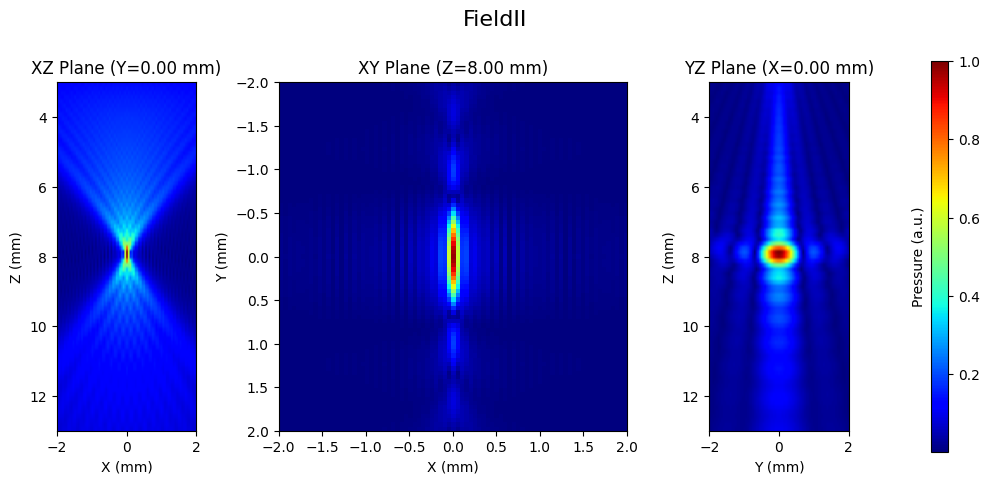

In [5]:

pyfield.plot_field_planes(data_dict['x'], data_dict['y'], data_dict['z'], data_dict['pr'], title='FieldII')

In [6]:
frequency_MHz = 12.5
c = 1540.0  # m/s

# ------- focus and simulation window (input parameters) -------
x_extent_mm = [-2, 2]
y_extent_mm = [-2, 2]
z_extent_mm = [3, 13]
dxyz = 0.05  # mm
sampling_frequency_MHz = 300.0
no_sub_x = 2
no_sub_y = 20

#  ------------------- transducer characteristics --------------------
dx_mm = dxyz
dy_mm = dxyz * np.diff(y_extent_mm) / np.diff(x_extent_mm)
dz_mm = dxyz * np.diff(z_extent_mm) / np.diff(x_extent_mm)
focus_mm = [0.0, 0.0, 8]

tx_N_elements = 128
tx_element_height_mm = 1.5
tx_width_mm = 0.108
tx_pitch_mm = 0.11
tx_kerf_mm = tx_pitch_mm - tx_width_mm
tx_elevationFocus_mm = 8.0
tx_frequency_Hz = frequency_MHz * 1e6

Create transducer

In [7]:
# Create transducer (Linear array equivalent)
tx = transducers.LinearArrayTransducer(
    n_elements=tx_N_elements,
    element_width_mm=tx_width_mm,
    element_height_mm=tx_element_height_mm,
    elevation_focus_mm=tx_elevationFocus_mm,
    kerf_mm=tx_kerf_mm,
    no_sub_x=no_sub_x,
    no_sub_y=no_sub_y,
    frequency_Hz=tx_frequency_Hz,
)

_ = tx.compute_delays(focus_mm=focus_mm)


LinearArrayTransducer initialized in 0.0481 seconds.


In [8]:
 # -------- DEFINE GRID (keep odd-number-of-points logic) --------

# Use PyField API which accepts a dictionary with extents and steps in mm
field_info_mm = {
    "x_extent": x_extent_mm,
    "y_extent": y_extent_mm,
    "z_extent": z_extent_mm,
    "dx": dx_mm,
    "dy": dy_mm,
    "dz": dz_mm,
}

# ------------------ Compute the field --------------------
field_solver = PyField(tx, fs=sampling_frequency_MHz * 1e6, c=c)



Min distance must be >> w^2/(4*lambda): 0.0114 mm


Compute field:

In [9]:
repetition = 0

for i in range(repetition+1):
    x, y, z, pr_naive = field_solver(
        field_info_mm, method = 'naive'
    )  # returns grids and field (pressure)

for i in range(repetition+1):
    x, y, z, pr_sdi = field_solver(
        field_info_mm, method = 'sdi'
    )  # returns grids and field (pressure)

for i in range(repetition+1):
    x, y, z, pr_auto = field_solver(
        field_info_mm, method = 'auto'
    )  # returns grids and field (pressure)


Computing SIR for 531441 points and 5120 patches...
Min distance: 2.97 mm, Max distance: 16.02 mm
Computed time grid from 1.89 us to 12.15 us, with 3079 samples in 1.92 seconds.
Transducer SIR computed in 16.030 seconds...
Pressure computed from SIR in 9.18 seconds...
Pressure field computed in 26.43 seconds... 


Computing SIR for 531441 points and 5120 patches...
Min distance: 2.97 mm, Max distance: 16.02 mm
Computed time grid from 1.89 us to 12.15 us, with 3079 samples in 0.69 seconds.
Transducer SIR computed in 9.066 seconds...
Pressure computed from SIR in 8.84 seconds...
Pressure field computed in 19.22 seconds... 


Computing SIR for 531441 points and 5120 patches...
Min distance: 2.97 mm, Max distance: 16.02 mm
Computed time grid from 1.89 us to 12.15 us, with 3079 samples in 0.66 seconds.
Transducer SIR computed in 12.764 seconds...
Pressure computed from SIR in 9.06 seconds...
Pressure field computed in 23.04 seconds... 



Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 41/81, 41/81, 41/81


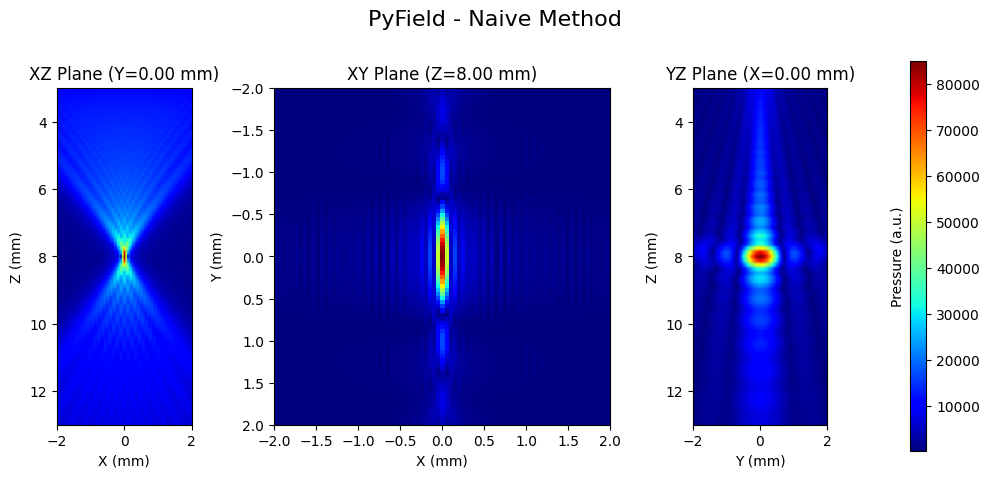

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 41/81, 41/81, 41/81


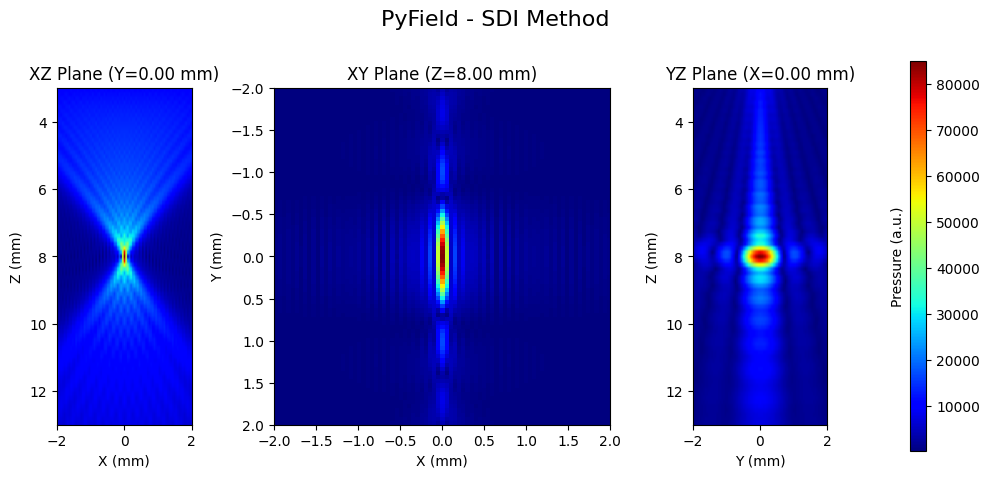

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 41/81, 41/81, 41/81


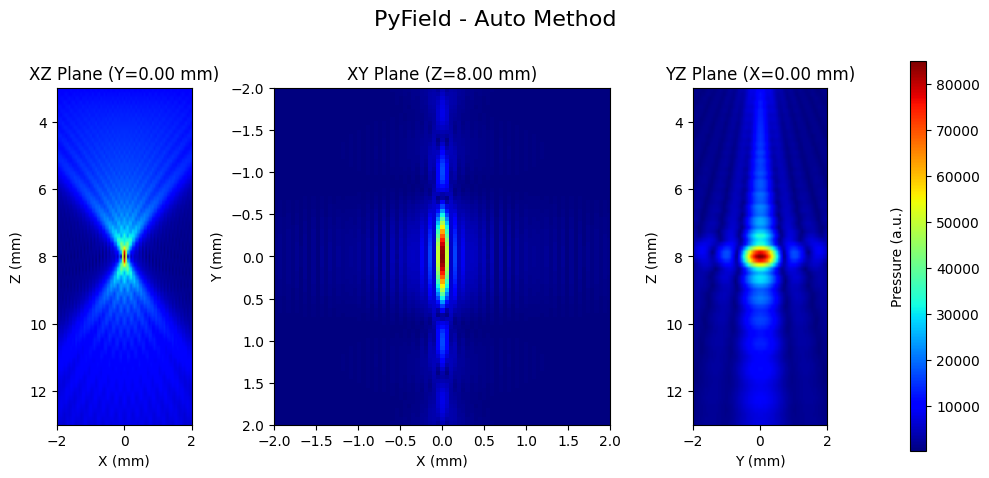

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 41/81, 41/81, 41/81


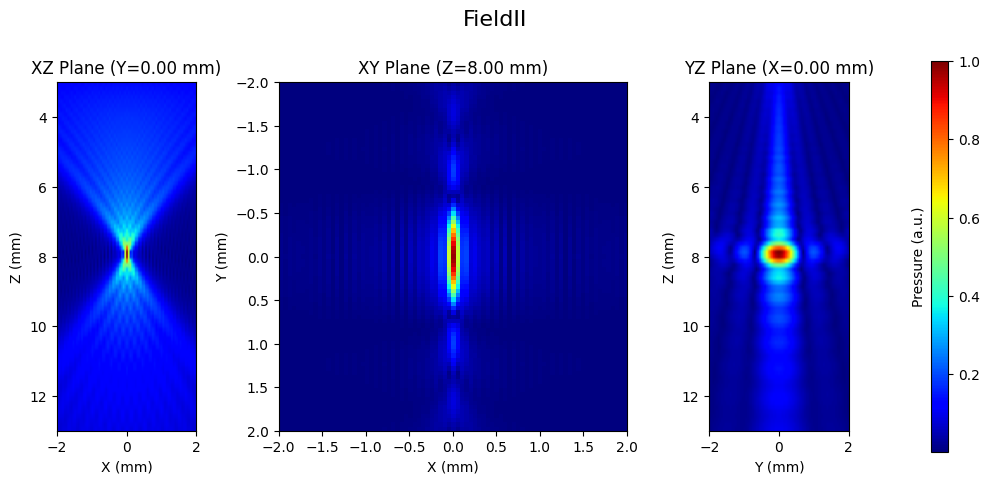

In [10]:
pyfield.plot_field_planes(x,y,z, pr_naive, title='PyField - Naive Method')
pyfield.plot_field_planes(x,y,z, pr_sdi  , title='PyField - SDI Method')
pyfield.plot_field_planes(x,y,z, pr_auto , title='PyField - Auto Method')
pyfield.plot_field_planes(data_dict['x'], data_dict['y'], data_dict['z'], data_dict['pr'], title='FieldII')

In [117]:
import pyfield.utilities.plotting_pyvista as pv_plotting
import pyvista as pv

def set_custom_style(plotter):
    cube_actor =plotter.show_bounds(
            grid = 'back', color = 'black', font_size = 12,
            location = 'outer',
            xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)",
            )
    # turn on outer gridlines and inner gridlines if you want them
    cube_actor.DrawXGridlinesOn()
    cube_actor.DrawYGridlinesOn()
    cube_actor.DrawZGridlinesOn()

    # set gridline colors to white (RGB in 0..1)
    cube_actor.GetXAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetYAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetZAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)

    # (optional) tweak gridline width
    cube_actor.GetXAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetYAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetZAxesGridlinesProperty().SetLineWidth(2.0)


    plotter.camera.up = (0, 0, -1)

def plot_volume(x,y,z, PII, *, notebook = False, image_name = None, off_screen = False, save_screenshot = False, **kwargs):
    # if image_name is None:
    window_size = (420,720)

    if image_name is not None:
        save_screenshot = True
        off_screen = True
    else:
        save_screenshot = False

    pv.global_theme.anti_aliasing = 'ssaa' 
    pressure_mesh = pv_plotting.create_vol_mesh(x, y, z, PII, scalars='Pressure')
    box = pressure_mesh.bounding_box()

    plotter = pv.Plotter(title='FD1 Real Data', notebook = notebook, window_size = window_size, off_screen= off_screen)
    _ = plotter.add_mesh(box,opacity=0.2, color='#b0b0b0')

    plotter = pv_plotting.add_pressure_vol(pressure_mesh, plotter=plotter, **kwargs)

    set_custom_style(plotter)

    if save_screenshot:
        plotter.screenshot(image_name)

    return plotter

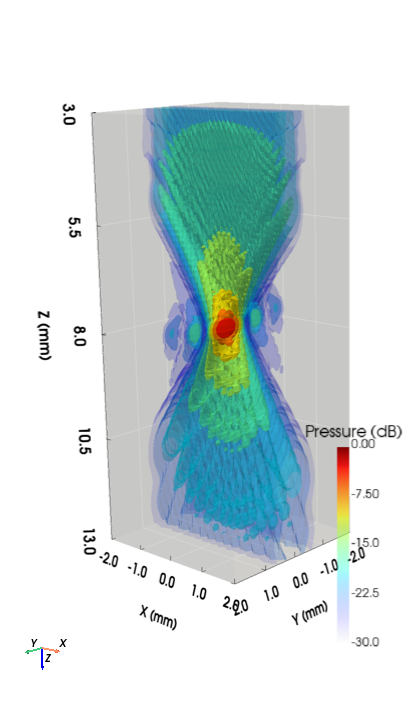

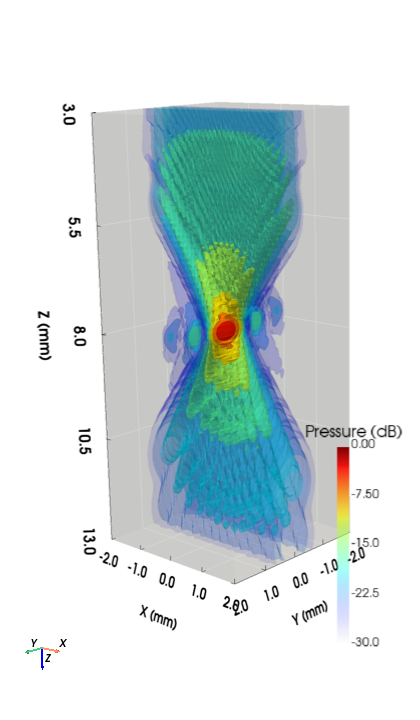

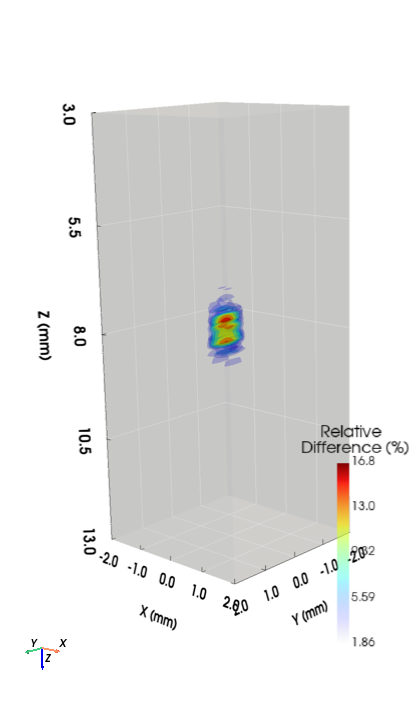

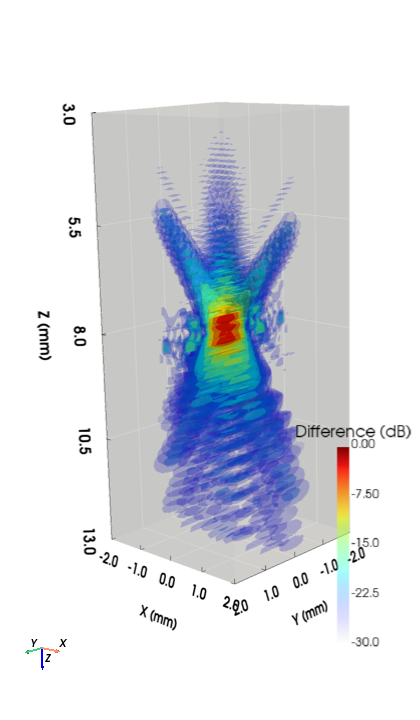

In [128]:
pr_naive_dB = pyfield.to_dB(pr_naive)
pr_fieldii_dB = pyfield.to_dB(data_dict['pr'])

plotter = plot_volume(x,y,z,pr_fieldii_dB, notebook = True, colorbar_title = 'Pressure (dB)', vmin = -30, ambient = 0.1)

plotter.camera_position = [(20.772320176481976, 21.620790361795066, 1.112337505414521),
 (-0.15341937499277186, 0.3905272279243004, 8.62966552023798),
 (-0.15225963054793556, -0.19313458649912463, -0.969286354181889)]
plotter.show(jupyter_backend='static')


plotter = plot_volume(x,y,z,pr_naive_dB, notebook = True, colorbar_title = 'Pressure (dB)', vmin = -30, ambient = 0.1)

plotter.camera_position = [(20.772320176481976, 21.620790361795066, 1.112337505414521),
 (-0.15341937499277186, 0.3905272279243004, 8.62966552023798),
 (-0.15225963054793556, -0.19313458649912463, -0.969286354181889)]
plotter.show(jupyter_backend='static')


diff_pr_naive_fieldII = abs(pr_naive/pr_naive.max() - data_dict['pr'])*100
plotter = plot_volume(x,y,z,diff_pr_naive_fieldII, notebook = True, colorbar_title = 'Relative \n Difference (%)', ambient = 0.1, vmin=0)

plotter.camera_position = [(20.772320176481976, 21.620790361795066, 1.112337505414521),
 (-0.15341937499277186, 0.3905272279243004, 8.62966552023798),
 (-0.15225963054793556, -0.19313458649912463, -0.969286354181889)]
plotter.show(jupyter_backend='static')

diff_pr_naive_fieldII = pyfield.to_dB(pr_naive/pr_naive.max() - data_dict['pr'])
plotter = plot_volume(x,y,z,diff_pr_naive_fieldII, notebook = True, colorbar_title = 'Difference (dB)', ambient = 0.1, vmin=-30)

plotter.camera_position = [(20.772320176481976, 21.620790361795066, 1.112337505414521),
 (-0.15341937499277186, 0.3905272279243004, 8.62966552023798),
 (-0.15225963054793556, -0.19313458649912463, -0.969286354181889)]
plotter.show(jupyter_backend='static')

In [83]:

pv.global_theme.anti_aliasing = "fxaa"
plotter = pv.Plotter(shape=(1,2), notebook=False)


plotter = pyfield.plot_pressure_field(x, y, z, pyfield.to_dB(pr_naive), plotter=plotter, vmin =-20)
# plotter.show(jupyter_backend='static')

plotter.subplot(0,1)

plotter = pyfield.plot_pressure_field(x, y, z, pyfield.to_dB(data_dict['pr']), plotter = plotter, vmin =-20)

plotter.show()

Pressure
Pressure


Taking slice (0.0,0.0,8.25) => x_ind, y_ind, z_ind = 41/81, 41/81, 43/81


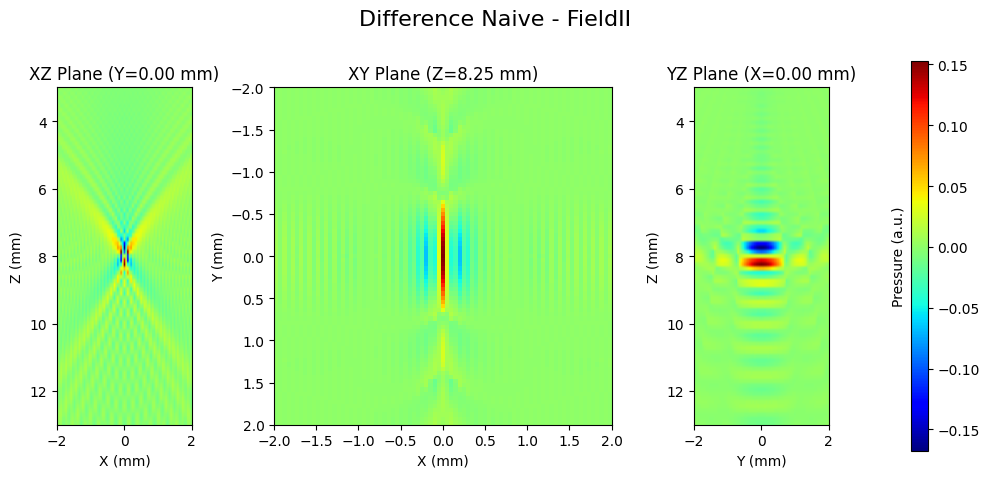

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 41/81, 41/81, 41/81


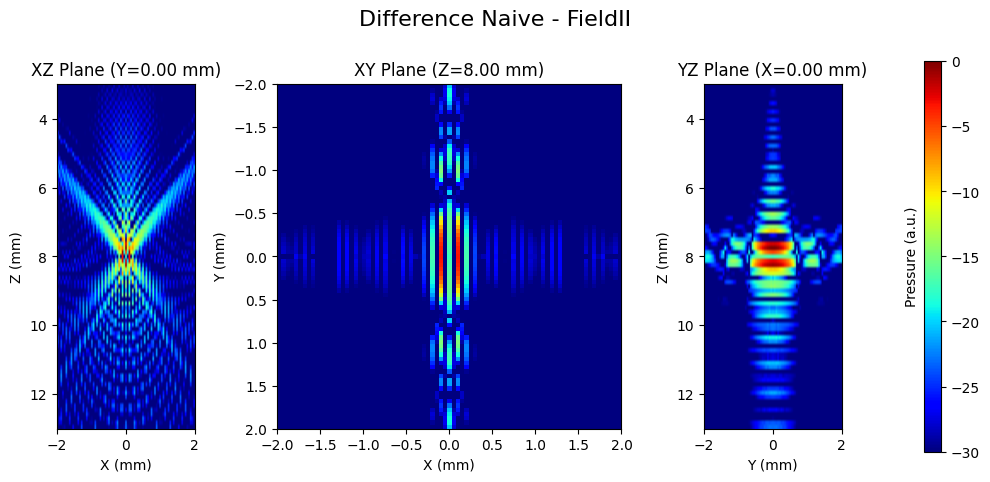

In [51]:
z_ind_shift = 0  # because of matlab 1-based indexing
if z_ind_shift > 0:
    diff_pr_naive_fieldII = (pr_naive/pr_naive.max())[:,:,:-z_ind_shift] - data_dict['pr'][:,:,z_ind_shift:]
elif z_ind_shift < 0:
    diff_pr_naive_fieldII = (pr_naive/pr_naive.max())[:,:, -z_ind_shift:] - data_dict['pr'][:,:,:z_ind_shift]
else:
    diff_pr_naive_fieldII = pr_naive/pr_naive.max() - data_dict['pr']


pyfield.plot_field_planes(data_dict['x'], data_dict['y'], data_dict['z'], diff_pr_naive_fieldII, title='Difference Naive - FieldII', centered_to_max=True)

pyfield.plot_field_planes(data_dict['x'], data_dict['y'], data_dict['z'], pyfield.to_dB(diff_pr_naive_fieldII), title='Difference Naive - FieldII', vmin=-30, vmax=0)

In [ ]:

diff_pr_sdi_fieldII = pr_sdi/pr_sdi.max() - data_dict['pr']
pyfield.plot_field_planes(data_dict['x'], data_dict['y'], data_dict['z'], diff_pr_sdi_fieldII, title='Difference SDI - FieldII')

In [12]:
h_time = field_solver.sir_running_time_log
print(h_time)

mean_times = [np.mean(h_time[start:start+repetition]) for start in [(repetition+1)*0+1,(repetition+1)*1+1,(repetition+1)*2+1]]
std_times = [np.std(h_time[start:start+repetition]) for start in [(repetition+1)*0+1,(repetition+1)*1+1,(repetition+1)*2+1]]
print("Mean times (s): Naive {:.4f}, SDI {:.4f}, Auto {:.4f}".format(*mean_times)+", FieldII {:.4f}".format(data_dict['mean_time']))
print("Std times (s): Naive {:.4f}, SDI {:.4f}, Auto {:.4f}".format(*std_times)+", FieldII {:.4f}".format(data_dict['std_time']))

[16.029786825180054, 9.065613508224487, 12.763784646987915]
Mean times (s): Naive nan, SDI nan, Auto nan, FieldII 140.6436
Std times (s): Naive nan, SDI nan, Auto nan, FieldII 0.0000


c:\Users\INSERM\Documents\Esteban\PyField\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\INSERM\Documents\Esteban\PyField\.venv\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\INSERM\Documents\Esteban\PyField\.venv\Lib\site-packages\numpy\_core\_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\INSERM\Documents\Esteban\PyField\.venv\Lib\site-packages\numpy\_core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\INSERM\Documents\Esteban\PyField\.venv\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
